# Example Notebook to Analyze Tactile Data

In [29]:
from utils import tactile_reading

pressure, fc, ts = tactile_reading('./recordings/recordings_2_1758753906.046783.hdf5')
print(pressure.shape)
# Should be (N, 16, 16) where N is the number of frames recorded

(1934, 16, 16)


## Timestamps are saved in unix time in seconds

In [30]:
print(f"Duration of recording: {ts[-1] - ts[0]} seconds")
print(f"Frame rate: {len(ts) / (ts[-1] - ts[0])} Hz")

Duration of recording: 65.94593715667725 seconds
Frame rate: 29.3270530890344 Hz


## Pressure values are recorded over time

Lower raw values indicate higher pressure

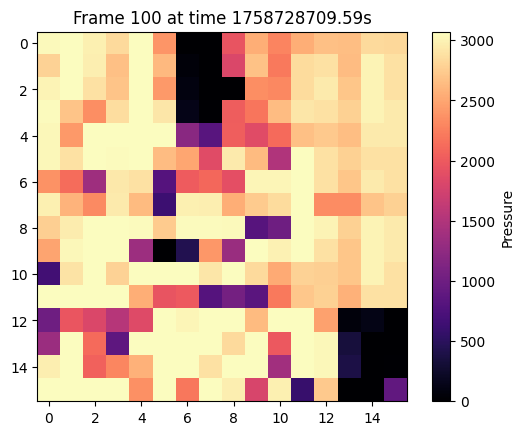

In [33]:
def plot_frame(frame_idx):
    import matplotlib.pyplot as plt
    plt.imshow(pressure[frame_idx], cmap='magma', interpolation='nearest')
    plt.colorbar(label='Pressure')
    plt.title(f'Frame {frame_idx} at time {ts[frame_idx]:.2f}s')
    plt.show()
plot_frame(100)

## Region-specific data

Regions are indicated as shown:

![hand regions](./handregions.png)


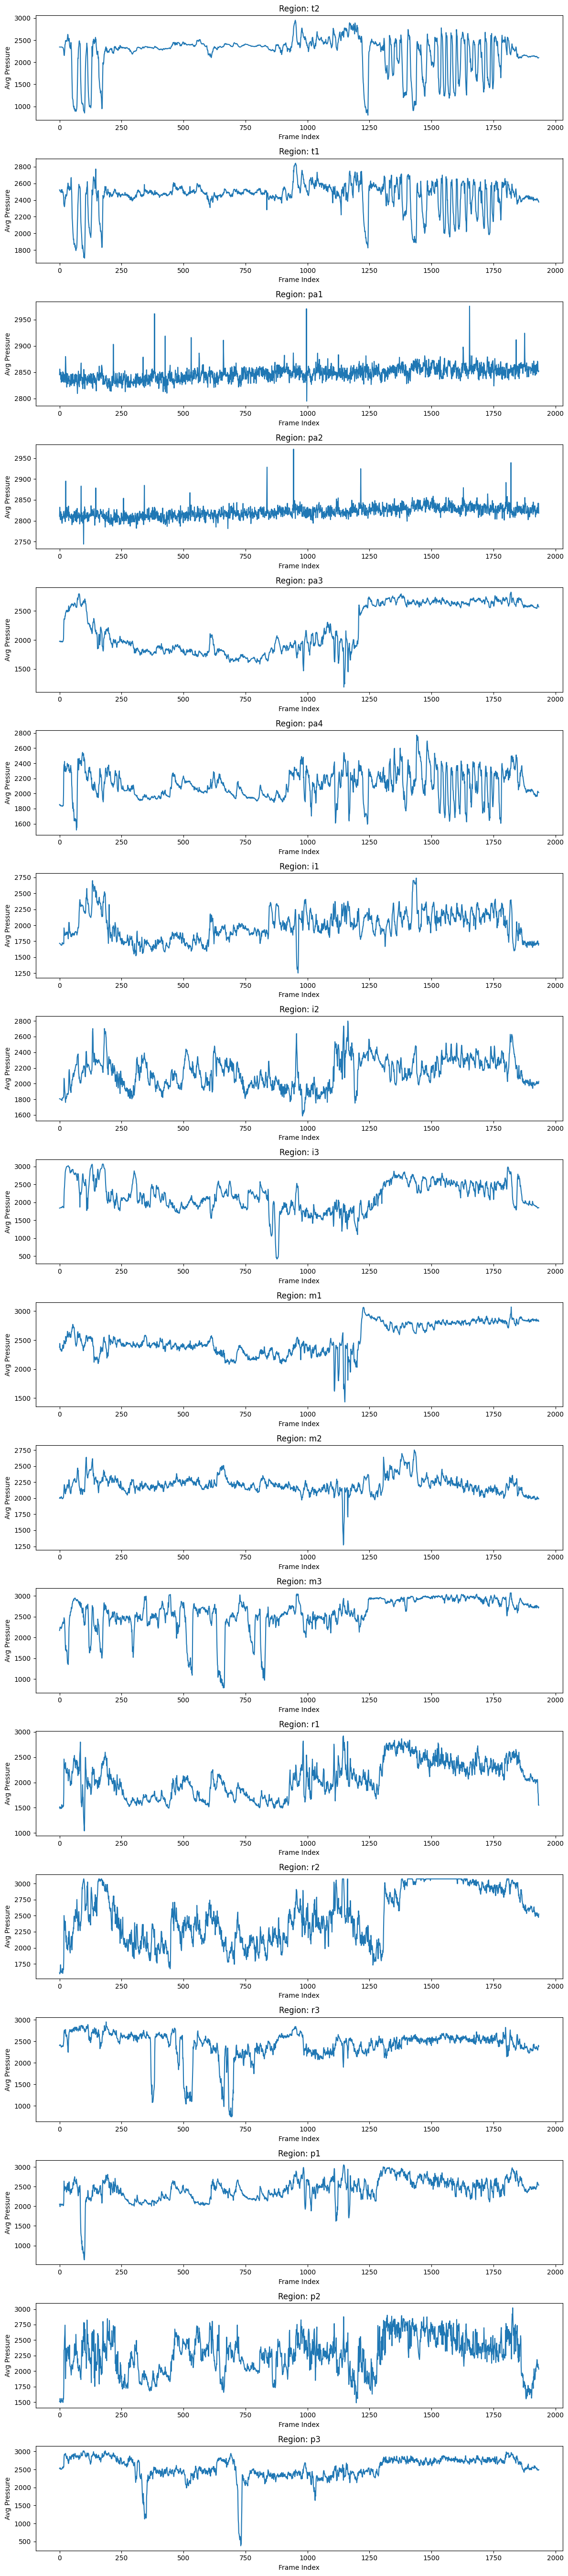

In [32]:

def flip_slices(regions, shape):
    H, W = shape
    flipped = {}
    for key, (rows, cols) in regions.items():
        flipped_rows = slice(H - rows.stop, H - rows.start)
        flipped_cols = slice(W - cols.stop, W - cols.start)
        flipped[key] = (flipped_rows, flipped_cols)
    return flipped

right_hand_regions = {
    't2':(slice(13,16), slice(12,16)),
    't1':(slice(11,13), slice(12,16)),
    'pa1':(slice(0,6), slice(12,16)),
    'pa2':(slice(6,11), slice(12,16)),
    'pa3':(slice(6,11), slice(9,12)),
    'pa4':(slice(0,6), slice(9,12)),
    'i1':(slice(9,11),slice(6,9)),
    'i2':(slice(9,11),slice(3,6)),
    'i3':(slice(9,11),slice(0,3)),
    'm1':(slice(6,8),slice(6,9)),
    'm2':(slice(6,8),slice(3,6)),
    'm3':(slice(6,8),slice(0,3)),
    'r1':(slice(3,5),slice(6,9)),
    'r2':(slice(3,5),slice(3,6)),
    'r3':(slice(3,5),slice(0,3)),
    'p1':(slice(0,2),slice(6,9)),
    'p2':(slice(0,2),slice(3,6)),
    'p3':(slice(0,2),slice(0,3)),
}

left_hand_region = flip_slices(right_hand_regions, (16, 16))

# Plot the average pressure in each region over time
def plot_region_averages(pressure, left_hand=True):
    import matplotlib.pyplot as plt
    import numpy as np

    if left_hand:
        regions = left_hand_region
    else:
        regions = right_hand_regions

    num_regions = len(regions)
    plt.figure(figsize=(12, num_regions * 3))  # Adjust size for many plots

    for i, (name, (rows, cols)) in enumerate(regions.items(), start=1):
        region_data = pressure[:, rows, cols]
        avg_pressure = np.mean(region_data, axis=(1, 2))

        plt.subplot(num_regions, 1, i)  # Each region gets its own subplot
        plt.plot(avg_pressure)
        plt.xlabel('Frame Index')
        plt.ylabel('Avg Pressure')
        plt.title(f'Region: {name}')
        plt.tight_layout()

    plt.show()

plot_region_averages(pressure, left_hand=False)